# 19: FD003 transfer FD001 pipeline comparison

Objetivo: aplicar directamente en FD003 el pipeline final seleccionado en FD001 y compararlo contra los resultados robustos finales de FD001.

Este notebook usa solamente `train_FD003.txt`: separa motores completos en train/validacion y evalua con cortes artificiales. No se carga `test_FD003.txt` ni `RUL_FD003.txt`.

## Setup

Pipeline transferido desde FD001: LightGBM temporal, `window_size=50`, `rul_cap=125`, `objective=quantile`, `alpha=0.40`, sin sample weights y con los hiperparametros finales guardados en config.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'CMAPSSData'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'FD003'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'fd003_transfer_fd001_pipeline'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'FD001' / 'fd001_final_quantile_candidate_notebook18_config.json'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 50
RUL_CAP = 125
CUT_RULS = (20, 50, 80, 110, 140)
ROBUSTNESS_STATES = [0, 1, 2, 3, 4]
DANGEROUS_ERROR_THRESHOLD = 20

sns.set_theme(style='whitegrid')


In [2]:
try:
    import lightgbm  # noqa: F401
except ImportError as exc:
    raise ImportError('Este notebook requiere LightGBM instalado; no se reemplaza por otro modelo.') from exc

from src.data import FEATURE_COLUMNS, add_train_rul
from src.fd003_transfer_utils import (
    evaluate_fd003_transfer_split,
    fd001_config_to_comparison_row,
    fd003_train_overview,
    load_fd003_train,
    fd003_feature_columns,
    fd003_summary_to_comparison_row,
    load_fd001_final_quantile_config,
    prepare_fd003_temporal_validation_only,
    summarize_fd003_transfer,
)


## 1. Carga e inspeccion de FD003

In [3]:
train_raw = load_fd003_train(DATA_DIR)
overview = fd003_train_overview(train_raw)
display(pd.DataFrame([overview]).T.rename(columns={0: 'value'}))

print('Columnas normalizadas del repo: unit/cycle equivalen a unit_number/time_in_cycles del enunciado original.')
print('Train columns:', train_raw.columns.tolist()[:8], '...')
print('Este notebook no carga test_FD003.txt ni RUL_FD003.txt.')


,value
train_shape,"(24720, 26)"
train_units,100
train_nulls,0
train_cycle_min,145
train_cycle_median,220.5
train_cycle_max,525


Columnas normalizadas del repo: unit/cycle equivalen a unit_number/time_in_cycles del enunciado original.
Train columns: ['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3'] ...
Este notebook no carga test_FD003.txt ni RUL_FD003.txt.


In [4]:
train_with_rul = add_train_rul(train_raw, max_rul=None)
train_with_rul['RUL_raw'] = train_with_rul['RUL']
train_with_rul['RUL_capped'] = train_with_rul['RUL'].clip(upper=RUL_CAP)
display(train_with_rul[['unit', 'cycle', 'RUL', 'RUL_capped']].head())
display(train_with_rul.groupby('unit')['cycle'].max().describe().to_frame('train_max_cycle'))


,unit,cycle,RUL,RUL_capped
0,1,1,258,125
1,1,2,257,125
2,1,3,256,125
3,1,4,255,125
4,1,5,254,125


,train_max_cycle
count,100.00000
mean,247.20000
std,86.48384
min,145.00000
25%,189.75000
50%,220.50000
75%,279.75000
max,525.00000


## 2. Columnas constantes detectadas en FD003

In [5]:
base_feature_columns, dropped_columns = fd003_feature_columns(train_with_rul)
print('Columnas de features eliminadas por varianza cero en train FD003:')
print(dropped_columns)
print('Features conservadas:', len(base_feature_columns), 'de', len(FEATURE_COLUMNS))


Columnas de features eliminadas por varianza cero en train FD003:
['setting_3', 'sensor_1', 'sensor_18', 'sensor_19']
Features conservadas: 20 de 24


## 3. Configuracion FD001 transferida

Se cargan hiperparametros reales desde el JSON final del notebook 18. No se hace tuning en FD003.

In [6]:
fd001_config = load_fd001_final_quantile_config(CONFIG_PATH)
assert fd001_config['objective'] == 'quantile'
assert float(fd001_config['alpha']) == 0.4
assert int(fd001_config['window_size']) == WINDOW_SIZE
assert int(fd001_config['rul_cap']) == RUL_CAP
assert fd001_config['sample_weight_scheme'] == 'none'
display(pd.DataFrame([fd001_config['hyperparameters']]).T.rename(columns={0: 'value'}))


,value
colsample_bytree,0.80
learning_rate,0.03
max_depth,-1.00
min_child_samples,10.00
n_estimators,1300.00
num_leaves,15.00
reg_alpha,0.50
reg_lambda,10.00
subsample,0.90


## 4. Validacion artificial multi-split en FD003

In [7]:
detail_rows = []
prediction_tables = []

for state in ROBUSTNESS_STATES:
    print(f'Split random_state={state}')
    prepared = prepare_fd003_temporal_validation_only(
        data_dir=DATA_DIR,
        eval_size=0.2,
        random_state=state,
        max_rul=RUL_CAP,
        cut_ruls=CUT_RULS,
        window_size=WINDOW_SIZE,
        drop_columns=dropped_columns,
    )
    row, predictions = evaluate_fd003_transfer_split(prepared, fd001_config, random_state=state)
    detail_rows.append(row)
    prediction_tables.append(predictions)

validation_detail = pd.DataFrame(detail_rows)
fd003_predictions = pd.concat(prediction_tables, ignore_index=True)
validation_summary = summarize_fd003_transfer(validation_detail)

validation_detail.to_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_detail.csv', index=False)
validation_summary.to_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_summary.csv', index=False)

display(validation_detail[[
    'random_state', 'n_eval', 'mae', 'rmse', 'r2', 'cmapss_score',
    'dangerous_error_pct', 'conservative_error_pct', 'bias_mean', 'n_features'
]])
display(validation_summary.T)


Split random_state=0


Split random_state=1


Split random_state=2


Split random_state=3


Split random_state=4


,random_state,n_eval,mae,rmse,r2,cmapss_score,dangerous_error_pct,conservative_error_pct,bias_mean,n_features
0,0,100,12.656875,18.101480,0.817965,451.737096,3.0,20.0,-7.653609,140
1,1,100,11.493399,15.129416,0.872834,392.595979,9.0,7.0,-0.654452,140
2,2,100,12.953675,18.183572,0.816310,555.049531,5.0,17.0,-4.827352,140
3,3,100,11.863795,15.192229,0.871776,332.703404,6.0,10.0,-1.644134,140
4,4,100,11.431411,15.636422,0.864168,390.065060,5.0,13.0,-3.185926,140


,0
dataset,FD003
model_name,candidate_03_B_quantile_a040_search_14
model_family,LightGBM
objective,quantile
alpha,0.4
sample_weight_scheme,none
window_size,50
rul_cap,125
mean_mae,12.079831
std_mae,0.690581


## 5. Comparacion FD001 vs FD003

In [8]:
comparison = pd.DataFrame([
    fd001_config_to_comparison_row(fd001_config),
    fd003_summary_to_comparison_row(validation_summary),
])
comparison.to_csv(RESULTS_DIR / 'fd003_vs_fd001_transfer_comparison.csv', index=False)
display(comparison)


,dataset,model,window,cap,objective,alpha,mean_mae,mean_rmse,mean_r2,mean_cmapss_score,mean_dangerous_error_pct,mean_conservative_error_pct,mean_bias,worst_rmse,worst_cmapss_score
0,FD001,candidate_03_B_quantile_a040_search_14,50,125,quantile,0.4,11.656848,15.087995,0.871886,307.444648,5.044692,14.861018,-3.127690,16.925379,398.125028
1,FD003,candidate_03_B_quantile_a040_search_14,50,125,quantile,0.4,12.079831,16.448624,0.848610,424.430214,5.600000,13.400000,-3.593095,18.183572,555.049531


In [9]:
fd003_config = {
    'dataset': 'FD003',
    'source_pipeline': 'FD001 final quantile candidate from notebook 18',
    'model_family': fd001_config['model_family'],
    'model_name': fd001_config['model_name'],
    'representation': 'temporal',
    'window_size': WINDOW_SIZE,
    'rul_cap': RUL_CAP,
    'objective': fd001_config['objective'],
    'alpha': fd001_config['alpha'],
    'sample_weight_scheme': fd001_config['sample_weight_scheme'],
    'hyperparameters': fd001_config['hyperparameters'],
    'fd003_dropped_zero_variance_columns': dropped_columns,
    'validation_protocol': 'artificial cutoffs by held-out units, multi-split robustness',
    'random_states': ROBUSTNESS_STATES,
    'test_files_loaded': False,
    'official_test_used_for_model_selection': False,
    'official_test_metrics_computed': False,
    'dangerous_error_threshold': DANGEROUS_ERROR_THRESHOLD,
    'outputs': {
        'validation_detail': 'results/FD003/fd003_transfer_fd001_pipeline_validation_detail.csv',
        'validation_summary': 'results/FD003/fd003_transfer_fd001_pipeline_validation_summary.csv',
        'comparison': 'results/FD003/fd003_vs_fd001_transfer_comparison.csv',
    },
}
with open(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_config.json', 'w', encoding='utf-8') as file:
    json.dump(fd003_config, file, indent=2, ensure_ascii=False)
print(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_config.json')


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003\fd003_transfer_fd001_pipeline_config.json


FD003 puede empeorar respecto de FD001 aunque mantenga una sola condicion operativa, porque incorpora dos modos de falla. Esa mezcla puede hacer que la relacion sensores-RUL sea menos unica que en FD001, por lo que un pipeline calibrado en FD001 puede transferir razonablemente pero no necesariamente optimizar el trade-off C-MAPSS/RMSE/dangerous error.

## 6. Graficos FD003

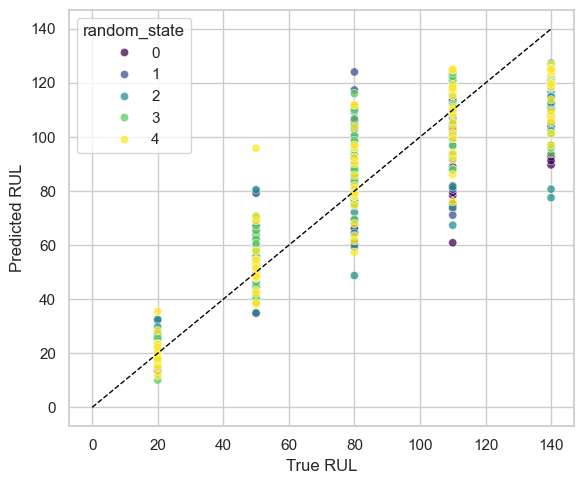

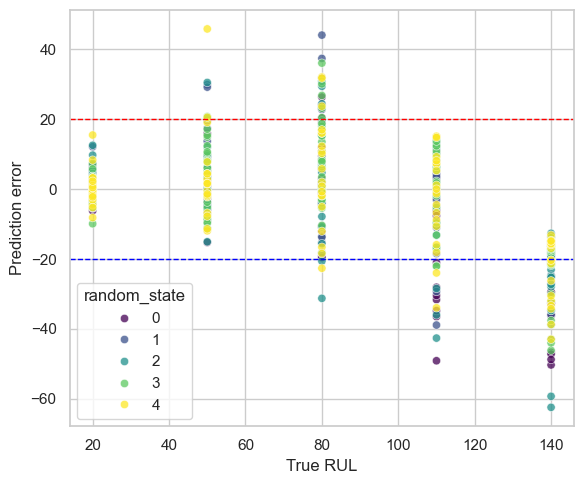

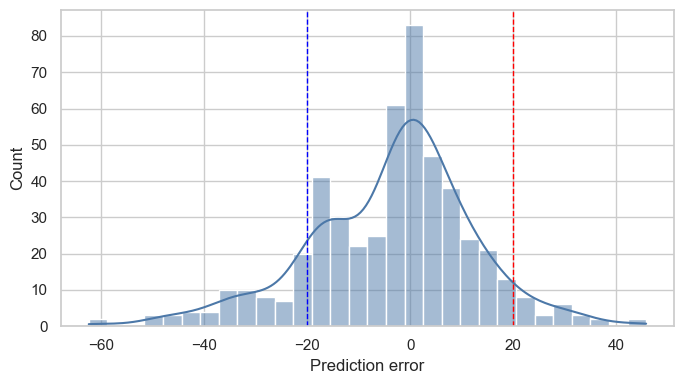

In [10]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=fd003_predictions, x='y_true_rul_raw', y='y_pred_rul', hue='random_state', alpha=0.75, palette='viridis')
max_axis = max(fd003_predictions['y_true_rul_raw'].max(), fd003_predictions['y_pred_rul'].max())
plt.plot([0, max_axis], [0, max_axis], color='black', linestyle='--', linewidth=1)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_predicted_vs_true.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=fd003_predictions, x='y_true_rul_raw', y='error', hue='random_state', alpha=0.75, palette='viridis')
plt.axhline(20, color='red', linestyle='--', linewidth=1)
plt.axhline(-20, color='blue', linestyle='--', linewidth=1)
plt.xlabel('True RUL')
plt.ylabel('Prediction error')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_error_vs_true_rul.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 4))
sns.histplot(fd003_predictions['error'], bins=30, kde=True, color='#4C78A8')
plt.axvline(20, color='red', linestyle='--', linewidth=1)
plt.axvline(-20, color='blue', linestyle='--', linewidth=1)
plt.xlabel('Prediction error')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_error_histogram.png', dpi=150)
plt.show()
plt.close()


,error_type,count,pct
0,dangerous,28,5.6
1,conservative,67,13.4
2,within_threshold,405,81.0


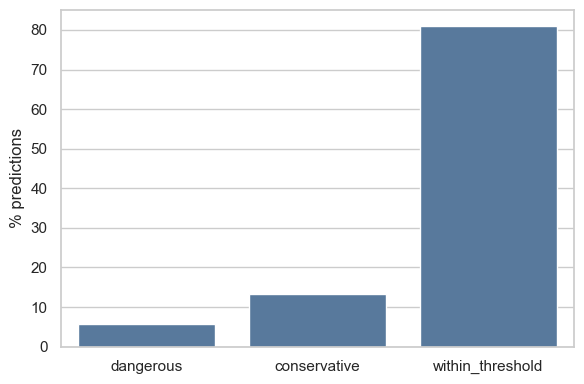

In [11]:
error_counts = pd.DataFrame({
    'error_type': ['dangerous', 'conservative', 'within_threshold'],
    'count': [
        int((fd003_predictions['error'] > 20).sum()),
        int((fd003_predictions['error'] < -20).sum()),
        int(((fd003_predictions['error'] <= 20) & (fd003_predictions['error'] >= -20)).sum()),
    ],
})
error_counts['pct'] = error_counts['count'] / error_counts['count'].sum() * 100
display(error_counts)

plt.figure(figsize=(6, 4))
sns.barplot(data=error_counts, x='error_type', y='pct', color='#4C78A8')
plt.ylabel('% predictions')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_error_type_distribution.png', dpi=150)
plt.show()
plt.close()


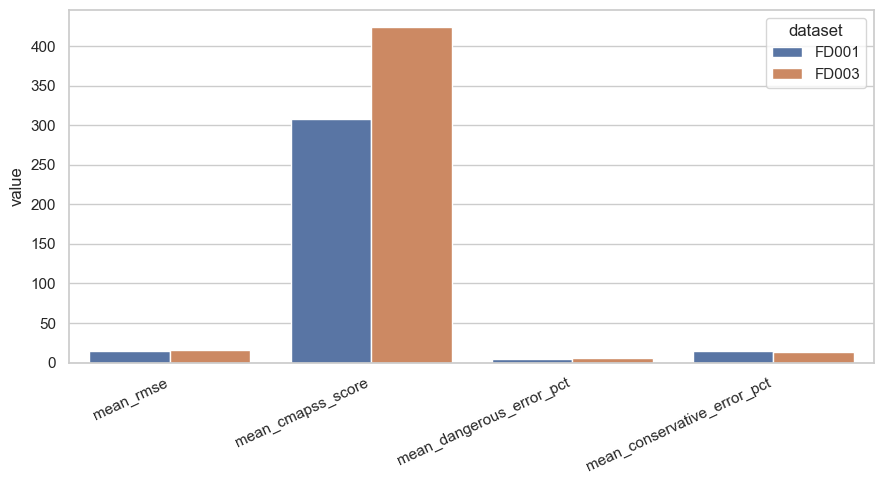

In [12]:
plot_metrics = comparison.melt(
    id_vars=['dataset'],
    value_vars=['mean_rmse', 'mean_cmapss_score', 'mean_dangerous_error_pct', 'mean_conservative_error_pct'],
    var_name='metric',
    value_name='value',
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_metrics, x='metric', y='value', hue='dataset')
plt.xticks(rotation=25, ha='right')
plt.xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_vs_fd001_metric_comparison.png', dpi=150)
plt.show()
plt.close()


## Cierre

Este notebook responde que ocurre al aplicar directamente el pipeline final de FD001 sobre FD003. No se hizo tuning en FD003 y no se usaron metricas oficiales de test para elegir el modelo. La decision de si conviene ajustar hiperparametros especificos para FD003 queda para un notebook posterior.